# Time Series Modeling with Satellite Data #

This notebook will explore the modeling and predicting soil moisture data obtained through soil stations and satellite data using ARIMA and neural networks.

https://www.tensorflow.org/tutorials/structured_data/time_series

In [1]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

import warnings
warnings.filterwarnings("ignore")

## Download data ##

In [2]:
folder_addr = "./merged_data/"
sm_df_list = {}
for i in range(6):
    df = pd.read_csv(folder_addr + 'Station' + str(i + 1) + '_Merged.csv')
    sm_df_list['Station' + str(i + 1)] = {
        'df': df,
        'dates': pd.to_datetime(df.pop('Date'))
    }

In [3]:
sm_df_list['Station1']['df'].head()

,Sat_SM,Ppt,SWC_5,SWC_10,SWC_20,SWC_50,T_5,T_10,T_20,T_50,Ppt.1,Tair,RH,Windspeed,Winddirection,Srad,Latitude,Longitude
0,0.224324,0.013512,0.171310,0.183661,0.158494,0.171167,18.310714,18.348571,18.318512,18.375119,0.013607,15.396964,74.542381,2.214155,173.944286,172.204821,30.3989,-98.6105
1,0.191104,0.003036,0.164131,0.181077,0.157208,0.170405,19.146905,19.014524,18.803512,18.474048,0.003024,17.210798,70.176905,2.314351,192.251845,204.373869,30.3989,-98.6105
2,0.210310,0.000000,0.155060,0.177470,0.155690,0.169685,20.045655,19.864762,19.577143,18.838036,0.000000,18.358595,68.807440,2.513542,202.383333,215.361131,30.3989,-98.6105
3,0.168200,0.000000,0.146554,0.173161,0.153798,0.168923,20.951429,20.718333,20.360179,19.300536,0.000000,19.392440,70.173571,2.653387,199.038095,213.818155,30.3989,-98.6105
4,0.167357,0.000000,0.139143,0.168560,0.151476,0.168071,21.845476,21.561726,21.136845,19.802083,0.000000,20.166548,70.561905,2.729702,198.314286,221.869821,30.3989,-98.6105


In [4]:
sm_df_list['Station1']['dates'].head()

0   2017-03-18
1   2017-03-19
2   2017-03-20
3   2017-03-21
4   2017-03-22
Name: Date, dtype: datetime64[ns]

## Feature Engineering ##

In [5]:
day = 24 * 60 * 60
year = 365.2425 * day
for station in sm_df_list.keys():
    df = sm_df_list[station]['df']
    dates = sm_df_list[station]['dates']
    wv = df.pop('Windspeed')
    timestamp_s = dates.map(pd.Timestamp.timestamp)
    lat = df.pop('Latitude')
    lon = df.pop('Longitude')
    wd_rad = df.pop('Winddirection') * np.pi / 180
    df['Wx'] = wv * np.cos(wd_rad)
    df['Wy'] = wv * np.sin(wd_rad)
    df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
    df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))
    df["x_cord"] = np.cos(lat) * np.cos(lon)
    df["y_cord"] = np.sin(lat) * np.cos(lon)
    df["z_cord"] = np.sin(lon)
    sm_df_list[station] = df

Text(0.5, 1.0, 'Time of year signal')

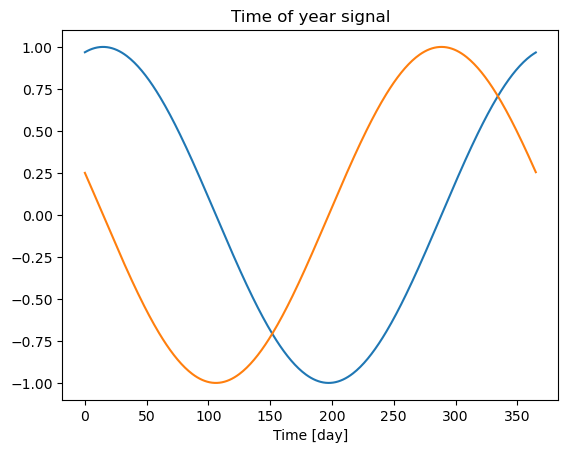

In [6]:
plt.plot(np.array(df['Year sin'])[:366])
plt.plot(np.array(df['Year cos'])[:366])
plt.xlabel('Time [day]')
plt.title('Time of year signal')

## Split and normalize the data ##

In [7]:
def split_data(df, target_col='SWC_5', train_split=0.7, val_split=0.2):
    n = len(df)
    targets = df[target_col]
    train_df = df[0:int(n*train_split)]
    val_df = df[int(n*train_split):int(n*(train_split + val_split))]
    test_df = df[int(n*(train_split + val_split)):]
    return train_df, val_df, test_df, targets

In [10]:
split_sm_df = {}
for station, df in sm_df_list.items():
    # Split the data
    train_df, val_df, test_df, targets = split_data(df)
    
    # Normalize the data
    train_mean = train_df.mean()
    train_std = train_df.std()

    train_df = (train_df - train_mean) / train_std
    val_df = (val_df - train_mean) / train_std
    test_df = (test_df - train_mean) / train_std
    
    # Add split and normalized data to map
    split_sm_df[station] = {
        'train': train_df,
        'val': val_df,
        'test': test_df,
        'target': targets
    }

## Data windowing ##

### Indexes and offsets ###

In [11]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 label_columns=None):
        # Store the raw data.
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        # Work out the label column indices.
        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_indices = {name: i for i, name in
                                        enumerate(label_columns)}
        self.column_indices = {name: i for i, name in
                               enumerate(train_df.columns)}

        # Work out the window parameters.
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        self.input_slice = slice(0, input_width)
        self.input_indices = np.arange(self.total_window_size)[self.input_slice]

        self.label_start = self.total_window_size - self.label_width
        self.labels_slice = slice(self.label_start, None)
        self.label_indices = np.arange(self.total_window_size)[self.labels_slice]

    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_indices}',
            f'Label indices: {self.label_indices}',
            f'Label column name(s): {self.label_columns}'])

In [12]:
STATION = 'Station1'
train_df = split_sm_df[STATION]['train']
val_df = split_sm_df[STATION]['val']
test_df = split_sm_df[STATION]['test']
w1 = WindowGenerator(input_width=24, label_width=1, shift=24,
                     train_df=train_df, val_df=val_df, test_df=test_df,
                     label_columns=['Sat_SM'])
w1

Total window size: 48
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Label indices: [47]
Label column name(s): ['Sat_SM']

In [14]:
w2 = WindowGenerator(input_width=6, label_width=1, shift=1,
                     train_df=train_df, val_df=val_df, test_df=test_df,
                     label_columns=['Sat_SM'])
w2

Total window size: 7
Input indices: [0 1 2 3 4 5]
Label indices: [6]
Label column name(s): ['Sat_SM']

### Split ###

In [15]:
def split_window(self, features):
    inputs = features[:, self.input_slice, :]
    labels = features[:, self.labels_slice, :]
    if self.label_columns is not None:
        labels = tf.stack(
            [labels[:, :, self.column_indices[name]] for name in self.label_columns],
            axis=-1)

    # Slicing doesn't preserve static shape information, so set the shapes
    # manually. This way the `tf.data.Datasets` are easier to inspect.
    inputs.set_shape([None, self.input_width, None])
    labels.set_shape([None, self.label_width, None])

    return inputs, labels

WindowGenerator.split_window = split_window

In [16]:
# Stack three slices, the length of the total window.
example_window = tf.stack([np.array(train_df[:w2.total_window_size]),
                           np.array(train_df[100:100+w2.total_window_size]),
                           np.array(train_df[200:200+w2.total_window_size])])

example_inputs, example_labels = w2.split_window(example_window)

print('All shapes are: (batch, time, features)')
print(f'Window shape: {example_window.shape}')
print(f'Inputs shape: {example_inputs.shape}')
print(f'Labels shape: {example_labels.shape}')

All shapes are: (batch, time, features)
Window shape: (3, 7, 21)
Inputs shape: (3, 6, 21)
Labels shape: (3, 1, 1)


2024-04-02 23:38:54.974991: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2024-04-02 23:38:54.975072: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2024-04-02 23:38:54.975088: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2024-04-02 23:38:54.975213: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-04-02 23:38:54.975545: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


### Plot ###

In [17]:
w2.example = example_inputs, example_labels

In [18]:
def plot(self, model=None, plot_col='Sat_SM', max_subplots=3):
    inputs, labels = self.example
    plt.figure(figsize=(12, 8))
    plot_col_index = self.column_indices[plot_col]
    max_n = min(max_subplots, len(inputs))
    for n in range(max_n):
        plt.subplot(max_n, 1, n+1)
        plt.ylabel(f'{plot_col} [normed]')
        plt.plot(self.input_indices, inputs[n, :, plot_col_index],
                 label='Inputs', marker='.', zorder=-10)

        if self.label_columns:
            label_col_index = self.label_columns_indices.get(plot_col, None)
        else:
            label_col_index = plot_col_index

        if label_col_index is None:
            continue

        plt.scatter(self.label_indices, labels[n, :, label_col_index],
                    edgecolors='k', label='Labels', c='#2ca02c', s=64)
        if model is not None:
            predictions = model(inputs)
            plt.scatter(self.label_indices, predictions[n, :, label_col_index],
                      marker='X', edgecolors='k', label='Predictions',
                      c='#ff7f0e', s=64)

        if n == 0:
            plt.legend()

    plt.xlabel('Time [d]')

WindowGenerator.plot = plot

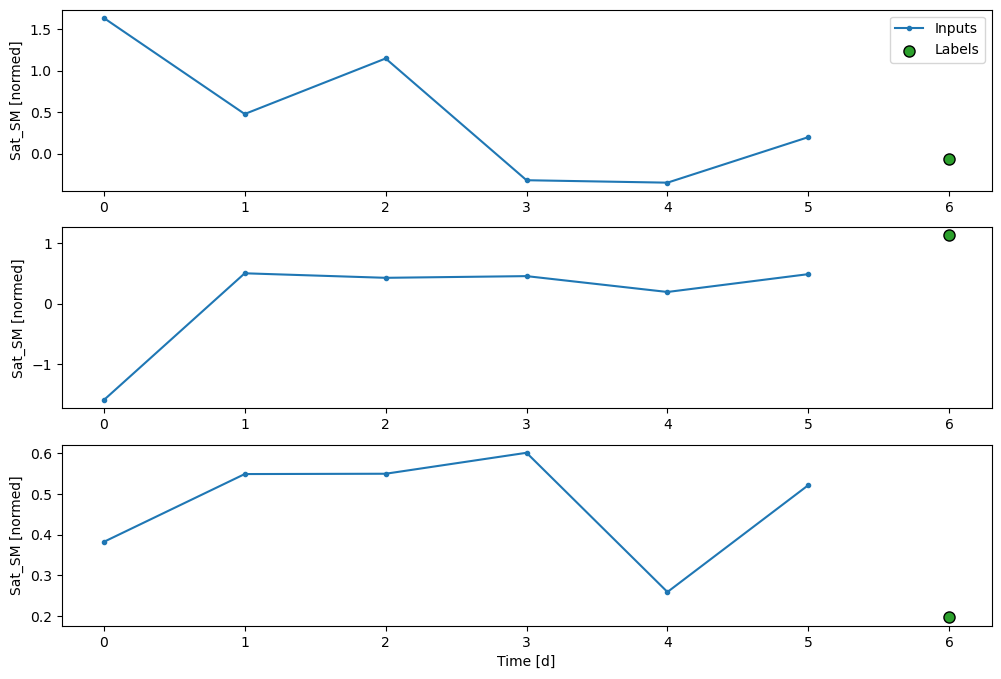

In [19]:
w2.plot()

### Create tf.data.Datasets ###

In [20]:
def make_dataset(self, data):
    data = np.array(data, dtype=np.float32)
    ds = tf.keras.utils.timeseries_dataset_from_array(
      data=data,
      targets=None,
      sequence_length=self.total_window_size,
      sequence_stride=1,
      shuffle=True,
      batch_size=32,)

    ds = ds.map(self.split_window)

    return ds

WindowGenerator.make_dataset = make_dataset

In [21]:
@property
def train(self):
    return self.make_dataset(self.train_df)

@property
def val(self):
    return self.make_dataset(self.val_df)

@property
def test(self):
    return self.make_dataset(self.test_df)

@property
def example(self):
    """Get and cache an example batch of `inputs, labels` for plotting."""
    result = getattr(self, '_example', None)
    if result is None:
        # No example batch was found, so get one from the `.train` dataset
        result = next(iter(self.train))
        # And cache it for next time
        self._example = result
    return result

WindowGenerator.train = train
WindowGenerator.val = val
WindowGenerator.test = test
WindowGenerator.example = example

In [22]:
# Each element is an (inputs, label) pair.
w2.train.element_spec

(TensorSpec(shape=(None, 6, 21), dtype=tf.float32, name=None),
 TensorSpec(shape=(None, 1, 1), dtype=tf.float32, name=None))

In [23]:
for example_inputs, example_labels in w2.train.take(1):
    print(f'Inputs shape (batch, time, features): {example_inputs.shape}')
    print(f'Labels shape (batch, time, features): {example_labels.shape}')

Inputs shape (batch, time, features): (32, 6, 21)
Labels shape (batch, time, features): (32, 1, 1)


## Models ##

In [24]:
def compile_and_fit(model, window, patience=2, nepochs=20):
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

    model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

    history = model.fit(window.train, epochs=nepochs,
                      validation_data=window.val,
                      callbacks=[early_stopping])
    return history